# <span style="color:green"> Numerical Simulation Laboratory </span>
## <span style="color:brown"> Python Exercise 11 </span>
## <span style="color:orange"> Keras - Neural Network regression </span>

### Overview 

In this notebook our task will be to perform machine learning regression on noisy data with a Neural Network (NN).

We will explore how the ability to fit depends on the structure of the NN. The goal is also to build intuition about why prediction is difficult.

This notebook is divide into four sections:

- [The Prediction Problem](#the-prediction-problem)  Definition of the problem and first neural network to approximate a target function.

- [11.1](#section-111) Analysis of the base network by varying epochs, σ, and training set size.

- [11.2](#section-112) Construction of a network to fit a 1D polynomial, varying depth, number of neurons, optimizer (Adam), and        loss functions (MSE, MAE).

- [11.3](#section-113) Extension to a two–variable function, using more complex networks to approximate nonlinear surfaces.




# The Prediction Problem

Consider a probabilistic process that gives rise to labeled data $(x,y)$. The data is generated by drawing samples from the equation

$$
    y_i= f(x_i) + \eta_i,
$$

where $f(x_i)$ is some fixed, but (possibly unknown) function, and $\eta_i$ is a Gaussian, uncorrelate noise variable such that

$$
\langle \eta_i \rangle=0 \\
\langle \eta_i \eta_j \rangle = \delta_{ij} \sigma
$$

We will refer to the $f(x_i)$ as the **true features** used to generate the data. 

To make predictions, we will consider a NN that depends on its parameters, weights and biases. The functions that the NN can model respresent the **model class** that we are using to try to model the data and make predictions.

To learn the parameters of the NN, we will train our models on a **training data set** and then test the effectiveness of the NN on a *different* dataset, the **validation data set**. The reason we must divide our data into a training and test dataset is that the point of machine learning is to make accurate predictions about new data we have not seen.

To measure our ability to predict, we will learn our parameters by fitting our training dataset and then making predictions on our test data set. One common measure of predictive  performance of our algorithm is to compare the predictions,$\{y_j^\mathrm{pred}\}$, to the true values $\{y_j\}$. A commonly employed measure for this is the sum of the mean square-error (MSE) on the test set:
$$
MSE= \frac{1}{N_\mathrm{test}}\sum_{j=1}^{N_\mathrm{test}} (y_j^\mathrm{pred}-y_j)^2
$$

We will try to get a qualitative picture by examining plots on validation and training data.

### Linear fit

We start by considering the very simple case:
$$
f(x)=2x+1
$$

Let's start defining the parameters of an ideal linear function which we are going to predict through a neural network regression

In [1]:
# target parameters of f(x) = m*x + b
m = 2 # slope
b = 1 # intersect

Now let's generate a set of input data which will slightly deviate from our ideal behaviour using a random noise (that actually is set to zero):

In [2]:
import numpy as np

# generate training inputs
np.random.seed(0)
x_train = np.random.uniform(-1, 1, 500)
x_valid = np.random.uniform(-1, 1, 50)
x_valid.sort()
y_target = m * x_valid + b # ideal (target) linear function

sigma = 0.5 # noise standard deviation, for the moment it is absent
y_train = np.random.normal(m * x_train + b, sigma) # actual measures from which we want to guess regression parameters
y_valid = np.random.normal(m * x_valid + b, sigma)

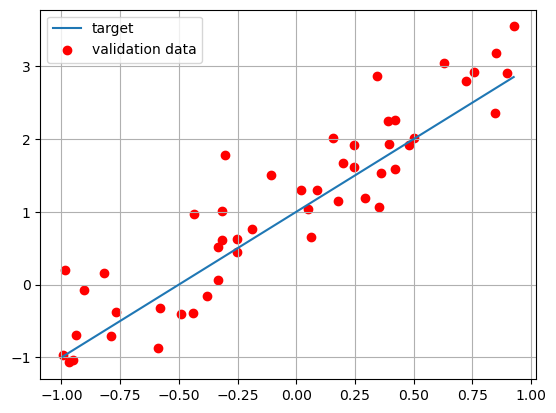

In [3]:
# plot validation and target dataset

import matplotlib.pyplot as plt
plt.plot(x_valid, y_target, label='target')
plt.scatter(x_valid, y_valid, color='r', label='validation data')
plt.legend()
plt.grid(True)
plt.show()

If you remember how a single node of a neural network works, you can easily spot that **just a single neuron can make the job**. So let's start using a simple Sequential model with just one layer on one neuron only!

In [4]:
# compose the NN model
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects

model = tf.keras.Sequential()
model.add(Dense(1, input_shape=(1,)))

# compile the model choosing optimizer, loss and metrics objects
model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

2025-09-16 11:36:01.091903: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/pietro34/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# get a summary of our composed model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

We are now going to train our model, that is we feed the neuron with the set of training pair x, y_train from which the optimizer will find the best weights to minimize the Mean Square Error loss function (out linear regression function).

In [6]:
# fit the model using training dataset
# over 10 epochs of 32 batch size each
# report training progress against validation data
history = model.fit(x=x_train, y=y_train, 
          batch_size=32, epochs=60,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          validation_data=(x_valid, y_valid))

Epoch 1/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.1700 - mse: 1.1700 - val_loss: 1.1364 - val_mse: 1.1364
Epoch 2/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8266 - mse: 0.8266 - val_loss: 0.8165 - val_mse: 0.8165
Epoch 3/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5411 - mse: 0.5411 - val_loss: 0.6270 - val_mse: 0.6270
Epoch 4/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4689 - mse: 0.4689 - val_loss: 0.5109 - val_mse: 0.5109
Epoch 5/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3939 - mse: 0.3939 - val_loss: 0.4380 - val_mse: 0.4380
Epoch 6/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3017 - mse: 0.3017 - val_loss: 0.3899 - val_mse: 0.3899
Epoch 7/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3261 - mse: 0.3261 - val_loss: 0.3567 - val_mse: 0.3567
Epoch 8/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2981 - mse: 0.2981 - val_loss: 0.3338 - val_mse: 0.3338
Epoch 9/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2912 - mse:

By looking at weights and biases we can see if the linear fit was successfull: $w_1$ represents the angular coefficient, $b$ the intercept.

In [7]:
# return weights and biases
model.get_weights()

[array([[2.0551932]], dtype=float32), array([0.94668937], dtype=float32)]

In [8]:
# evaluate model
score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.2840 - mse: 0.2840

Test loss: 0.2787933647632599
Test accuracy: 0.2787933647632599


In [9]:
# evaluate model with the exact curve
score = model.evaluate(x_valid, y_target, batch_size=32, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0048 - mse: 0.0048

Test loss: 0.004121831152588129
Test accuracy: 0.004121831152588129


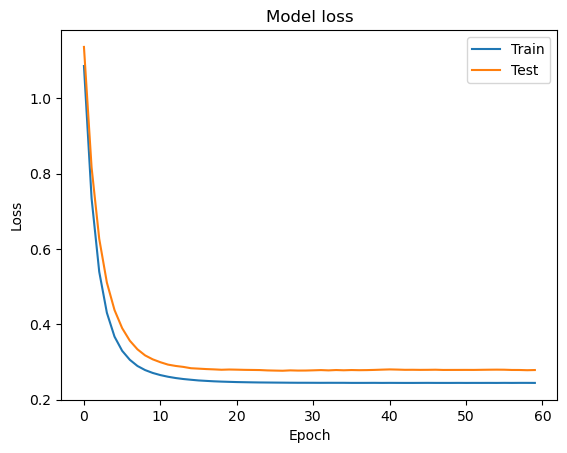

In [10]:
# look into training history
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


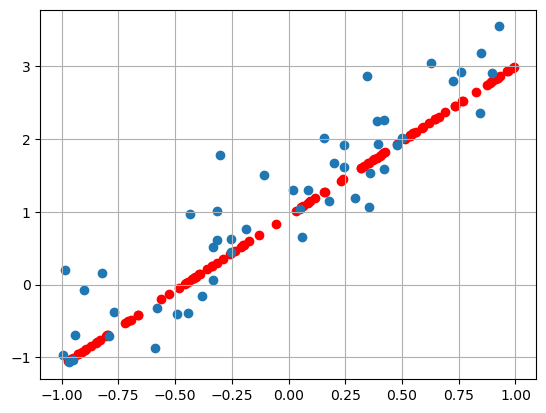

In [11]:
x_predicted = np.random.uniform(-1, 1, 100)
y_predicted = model.predict(x_predicted)
plt.scatter(x_predicted, y_predicted,color='r')
plt.scatter(x_valid, y_valid)
plt.grid(True)
plt.show()

In [12]:
import numpy as np
import matplotlib.pyplot as plt
# compose the NN model
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects

# target parameters of f(x) = m*x + b
m = 2 # slope
b = 1 # intersect

# 11.1 <a id="section-111"></a>

In this exercise, the neural network is trained to approximate a linear function.  
The objective is to investigate how the model’s performance depends on three key factors:  

1. **Number of training samples ($N_{train}$):**  
   A larger training set provides more information to the model, improving its ability to generalize.  
   
2. **Number of epochs ($N_{epochs}$):**  
   Increasing the number of epochs allows the optimizer to refine the weights more thoroughly, but beyond a certain point additional training provides little or no improvement.  
   
3. **Noise level ($\sigma$):**  
   Adding Gaussian noise to the dataset makes the learning task more challenging, since the network has to approximate the underlying signal in the presence of fluctuations.  

The same network architecture and hyperparameters were used for all tests, while varying one parameter at a time.  
The validation mean squared error (MSE) was measured in each case to evaluate the quality of the fit.


In [13]:
def train_model(N_train=500, N_epochs=60, sigma=0.5, seed=0):
    np.random.seed(seed)
    x_train = np.random.uniform(-1, 1, N_train)
    x_valid = np.random.uniform(-1, 1, 50)
    x_valid.sort()

    y_train = np.random.normal(m * x_train + b, sigma)
    y_valid = np.random.normal(m * x_valid + b, sigma)

    model = tf.keras.Sequential()
    model.add(Dense(1, input_shape=(1,)))
    model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

    history = model.fit(x_train, y_train, 
                        batch_size=32, 
                        epochs=N_epochs, 
                        validation_data=(x_valid, y_valid),
                        verbose=0, shuffle=True)

    val_mse = history.history['val_mse'][-1]  # ultimo valore MSE sulla validazione
    return val_mse, model

def plot_results(N_trains, results, epoch_list, results_epoch, sigma_list, results_sigma):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # --- Subplot 1: N_train ---
    axes[0].plot(N_trains, results, marker='o')
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    axes[0].set_xlabel("N_train")
    axes[0].set_ylabel("Validation MSE")
    axes[0].set_title("Learning Curve vs N_train")
    axes[0].grid(True)
    axes[0].set_xticks(N_trains)
    axes[0].get_xaxis().set_major_formatter(plt.ScalarFormatter())  # xticks leggibili

    # --- Subplot 2: N_epochs ---
    axes[1].plot(epoch_list, results_epoch, marker='o')
    axes[1].set_yscale('log')
    axes[1].set_xlabel("N_epochs")
    axes[1].set_ylabel("Validation MSE")
    axes[1].set_title("Learning Curve vs N_epochs")
    axes[1].grid(True)

    # --- Subplot 3: sigma ---
    axes[2].plot(sigma_list, results_sigma, marker='o')
    axes[2].set_xlabel("σ")
    axes[2].set_ylabel("Validation MSE")
    axes[2].set_title("Learning Curve vs σ")
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()


In [14]:
N_trains = [10, 50, 100, 200, 500, 1000, 2000,5000,10000]
results = []
for N in N_trains:
    mse, _ = train_model(N_train=N, N_epochs=60, sigma=0.1)
    results.append(mse)

epoch_list = [10, 20, 40, 60, 100, 200, 300, 500]
results_epoch = []
for epoch in epoch_list:
    #print(epoch)
    mse_epoch, _ = train_model(N_train=500, N_epochs=epoch, sigma=0.1)
    results_epoch.append(mse_epoch)

sigma_list=[0.0, 0.1 ,0.2 ,0.3 ,0.5 ,0.7, 0.9, 1.0]
results_sigma = []
for s in sigma_list:
    #print(s)
    mse_sigma, _ = train_model(N_train=500, N_epochs=60, sigma=s)
    results_sigma.append(mse_sigma)


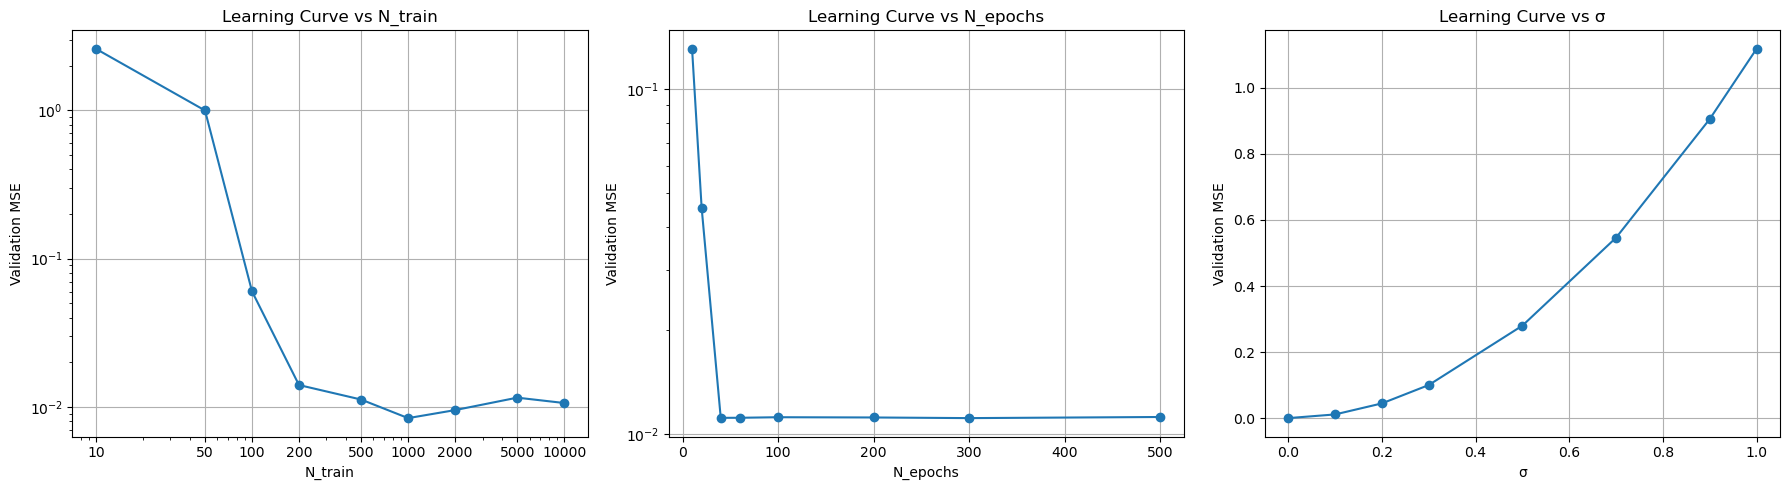

In [15]:
plot_results(N_trains, results, epoch_list, results_epoch, sigma_list, results_sigma)


The figure summarizes the dependence of the validation MSE on the three parameters:  

- **Dependence on $N_{train}$ (left panel):**  
  The error decreases rapidly as the number of training points increases, dropping by almost two orders of magnitude between $N_{train} = 10$ and $N_{train} = 200$.  
  Beyond a few thousand points, the error stabilizes around $10^{-2}$, indicating that additional samples provide only marginal improvements.  

- **Dependence on $N_{epochs}$ (center panel):**  
  The error decreases sharply up to about 40 epochs, after which it reaches a plateau near $10^{-2}$.  
  Additional epochs do not improve performance, showing that the network converges very quickly for this task.  

- **Dependence on $\sigma$ (right panel):**  
  As the noise amplitude increases, the validation error grows monotonically and almost quadratically, exceeding 1 for $\sigma = 1$.  
  This confirms that the main limitation in this case is not the network capacity but the statistical fluctuations present in the training set.  

Overall, the analysis demonstrates that the network achieves good generalization with a moderate training set and a limited number of epochs, while the presence of noise remains the dominant factor affecting performance.


# 11.2 <a id="section-112"></a>

The purpose of this exercise is to approximate a cubic polynomial function  

$$ f(x) = 4 - 3x - 2x^2 + 3x^3 $$  

using a feed-forward neural network.  
The goal is to analyze the impact of different architectural and training choices on the model performance, with particular attention to:  
- the number of hidden layers and the activation functions,  
- the number of neurons in the hidden layers,  
- the choice of the loss function and the optimizer,  
- the generalization capability outside the training domain.


In [16]:
#f(x)= a -b * x- c * x^2 + d * x^2
a=4
b=-3
c=-2
d=+3

def f(x):
    return 4-3*x-2*x**2+3*x**3

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects

 

In [17]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})
# train and valid data
def generate_data(N_train=500, sigma=0.1, seed=0):
    
    np.random.seed(seed)
    x_train = np.random.uniform(-1, 1, N_train)
    x_valid = np.linspace(-1, 1, 200)
    y_train = np.random.normal(f(x_train), sigma)
    y_valid = f(x_valid)  # niente rumore per il confronto visivo
    return x_train, y_train, x_valid, y_valid



def set_model(N_layer, N_neurons, act, optimazer='sgd',loss='mse'):
    tf.random.set_seed(0)
    model = tf.keras.Sequential()
    #first layer of the network
    model.add(Dense(N_neurons, activation =act,input_shape=(1,)))
    #secondary layers :
    for l in range(N_layer):
        model.add(Dense(N_neurons, activation = act ))
    #last layer
    model.add(Dense(1))
    model.compile(optimizer='sgd', loss='mse', metrics=['mse'])  
    
    return model

def set_model_neurons(Neurons_list, act='tanh', optimizer='sgd', loss='mse'):
    tf.random.set_seed(0)
    model = tf.keras.Sequential()
    
    # First layer: 
    model.add(Dense(Neurons_list[0], activation=act, input_shape=(1,)))
    # Hidden Layers 
    for n in Neurons_list[1:]:
        model.add(Dense(n, activation=act))

    # Layer di output
    model.add(Dense(1))
    
    # Compila il modello
    model.compile(optimizer=optimizer, loss=loss, metrics=['mse'])
    
    return model  
    
def good_arch(act='tanh',optimizer='adam', loss='mse'):
    tf.random.set_seed(0)
    model = tf.keras.Sequential()
    model.add(Dense(5, activation=act, input_shape=(1,)))
   
    model.add(Dense(10, activation=act))
    model.add(Dense(15, activation=act))
    model.add(Dense(20, activation=act))

    # Layer di output
    model.add(Dense(1))
    
    # Compila il modello
    model.compile(optimizer=optimizer, loss=loss, metrics=[loss])
    return model
    

def train_model(model, x_train, y_train, N_epochs=50):
    history = model.fit(x_train, y_train,
                        validation_split=0.2,
                        epochs=N_epochs,
                        batch_size=32,
                        verbose=0)
    return model, history   #ritorna il modello allenato

def plot_fit_and_loss(model, history, x_valid, y_valid):
    y_pred = model.predict(x_valid)

    fig, axs = plt.subplots(1, 2, figsize=(14, 6))

    # Subplot 1: f(x) vs y_pred(x)
    axs[0].plot(x_valid, f(x_valid), label='f(x)', color='black')
    axs[0].plot(x_valid, y_pred, label='NN prediction', marker='o',markersize=0.5,linestyle='None',color='r')
    axs[0].set_title('Funzione target vs predizione NN')
    axs[0].set_xlabel('x')
    axs[0].set_ylabel('y')
    axs[0].legend()
    axs[0].grid(True)

    # Subplot 2: train vs validation loss
    axs[1].plot(history.history['loss'], label='train loss')
    axs[1].plot(history.history['val_loss'], label='validation loss')
    axs[1].set_title('Loss ')
    axs[1].set_xlabel('Epoca')
    axs[1].set_ylabel('MSE')
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

def plot_fits(models, labels, x_valid, y_valid, title):
    
    plt.figure(figsize=(10, 6))
    for model, label in zip(models, labels):
        y_pred = model.predict(x_valid)
        plt.plot(x_valid, y_pred, label=f'{label} layers', linestyle='None', marker='o',markersize=1)
    plt.plot(x_valid, f(x_valid), color='black', label='function')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_fits_subplots(models_by_activation, activation_labels, x_valid, y_valid, title_prefix):
    fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharey=True)

    for ax, models, activation_label in zip(axes, models_by_activation, activation_labels):
        for i, model in enumerate(models, 1):
            y_pred = model.predict(x_valid)
            ax.plot(x_valid, y_pred, label=f'{i} hidden layers', linestyle='None', marker='o', markersize=1)
        
        ax.plot(x_valid, f(x_valid), color='black', label='function')
        ax.set_title(f"{title_prefix} - {activation_label}")
        ax.set_xlabel('x')
        ax.grid(True)
        ax.legend()

    axes[0].set_ylabel('y')
    plt.tight_layout()
    plt.show()

def plot_3_fits_subplots(models, x_valid, y_valid, title):
    fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharey=True)

    for ax, model, title in zip(axes, models, titles):
        y_pred = model.predict(x_valid)
        ax.plot(x_valid, y_pred, linestyle='None', marker='o', markersize=2.5, label='Prediction')
        ax.plot(x_valid, f(x_valid), color='black', label='Target function')
        ax.set_title(f'Architecture {title}')
        ax.set_xlabel('x')
        ax.grid(True)
        ax.legend()
    
    axes[0].set_ylabel('y')
    plt.tight_layout()
    plt.show()



def plot_good(models, histories, x_valid, y_valid, loss_names):
    fig, axes = plt.subplots(2, 2, figsize=(20, 8))

    for i in range(2):
        model = models[i]
        history = histories[i]
        loss_name = loss_names[i]
        
        # Prediction subplot (colonna 0)
        y_pred = model.predict(x_valid)
        axes[i, 0].plot(x_valid, y_pred, 'o', markersize=2.5, label='Prediction')
        axes[i, 0].plot(x_valid, f(x_valid), 'k-', label='Target f(x)')
        axes[i, 0].set_title(f'Prediction - Loss: {loss_name}')
        axes[i, 0].set_xlabel('x')
        axes[i, 0].set_ylabel('y')
        axes[i, 0].grid(True)
        axes[i, 0].legend()

        # Loss subplot (colonna 1)
        axes[i, 1].plot(history.history['loss'], label='Train Loss')
        if 'val_loss' in history.history:
            axes[i, 1].plot(history.history['val_loss'], label='Validation Loss')
        axes[i, 1].set_title(f'Loss curve - {loss_name}')
        axes[i, 1].set_xlabel('Epoch')
        axes[i, 1].set_ylabel('Loss')
        axes[i, 1].grid(True)
        axes[i, 1].legend()

    plt.tight_layout()
    plt.show()

    

In [18]:
# ARCHITECTURE-ACTIVATION: ELU
x_train, y_train, x_valid, y_valid = generate_data(N_train=5000)
N_layer=[1,2,3,4,5]
models_elu=[]
histories_elu=[]
for N in N_layer:
    model= set_model(N,N_neurons=5,act='elu')
    model, history = train_model(model , x_train, y_train, N_epochs=50)
    models_elu.append(model)
    histories_elu.append(history)

In [19]:
# ARCHITECTURE-ACTIVATION: RELU 
x_train, y_train, x_valid, y_valid = generate_data(N_train=5000)
N_layer=[1,2,3,4,5]
models_relu=[]
histories_relu=[]
for N in N_layer:
    model= set_model(N,N_neurons=5,act='relu')
    model, history = train_model(model , x_train, y_train, N_epochs=50)
    models_relu.append(model)
    histories_relu.append(history)

In [20]:
#FIRST ARCHITECTURE-ACTIVATION: TANH
x_train, y_train, x_valid, y_valid = generate_data(N_train=5000)
N_layer=[1,2,3,4,5]
models_tanh=[]
histories_tanh=[]
for N in N_layer:
    model= set_model(N,N_neurons=5,act='tanh')
    model, history = train_model(model , x_train, y_train, N_epochs=50)
    models_tanh.append(model)
    histories_tanh.append(history)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


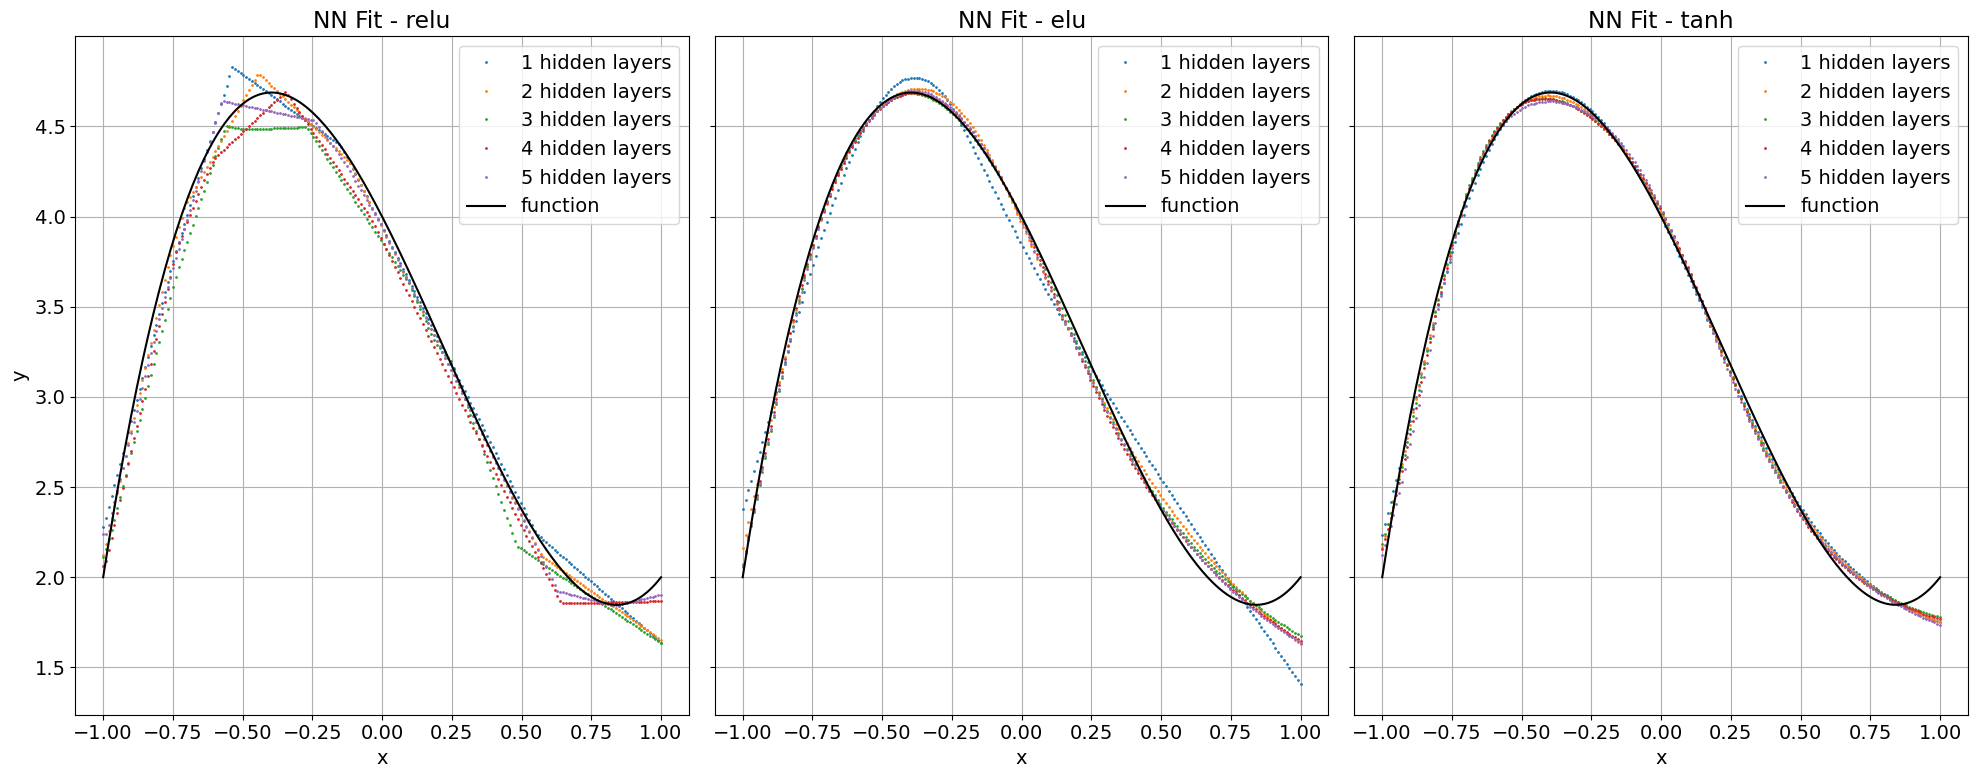

In [21]:
activation_labels=['relu', 'elu', 'tanh']
models_activation=[models_relu,models_elu,models_tanh]
plot_fits_subplots(models_activation, activation_labels, x_valid, y_valid, "NN Fit")


The figure compares the approximation of the target polynomial function using different depths and activation functions.  

- **ReLU (left panel):** The fits are less smooth, especially for shallow architectures, with visible discontinuities and poor behavior near the extrema.  
- **ELU (center panel):** The approximation improves compared to ReLU, but the predictions still deviate from the exact curve in some regions.  
- **Tanh (right panel):** The approximation is significantly more accurate and stable. Even with only a few layers, the network is able to capture the shape of the polynomial.  

**Conclusion:** The Tanh activation function with four hidden layers provides the most reliable and accurate results. Therefore, it was selected for the subsequent analysis.


## Effect of the number of neurons

After fixing Tanh as the activation function, the number of neurons in each hidden layer was varied to test the effect of model capacity.  
Three different configurations were tested: [10, 10, 10, 10], [5, 10, 15, 20], and [5, 20, 20, 5].


In [26]:
neurons_list = [
    [10, 10, 10, 10],
    [5, 10, 15, 20 ],
    [5, 20, 20, 5]
]

models = []
titles = ['[10, 10, 10, 10]', '[5, 10, 15, 20 ]', '[5, 20, 20, 5]']

for neurons in neurons_list:
    model = set_model_neurons(neurons)
    model, _ = train_model(model, x_train, y_train, N_epochs=50)
    models.append(model)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


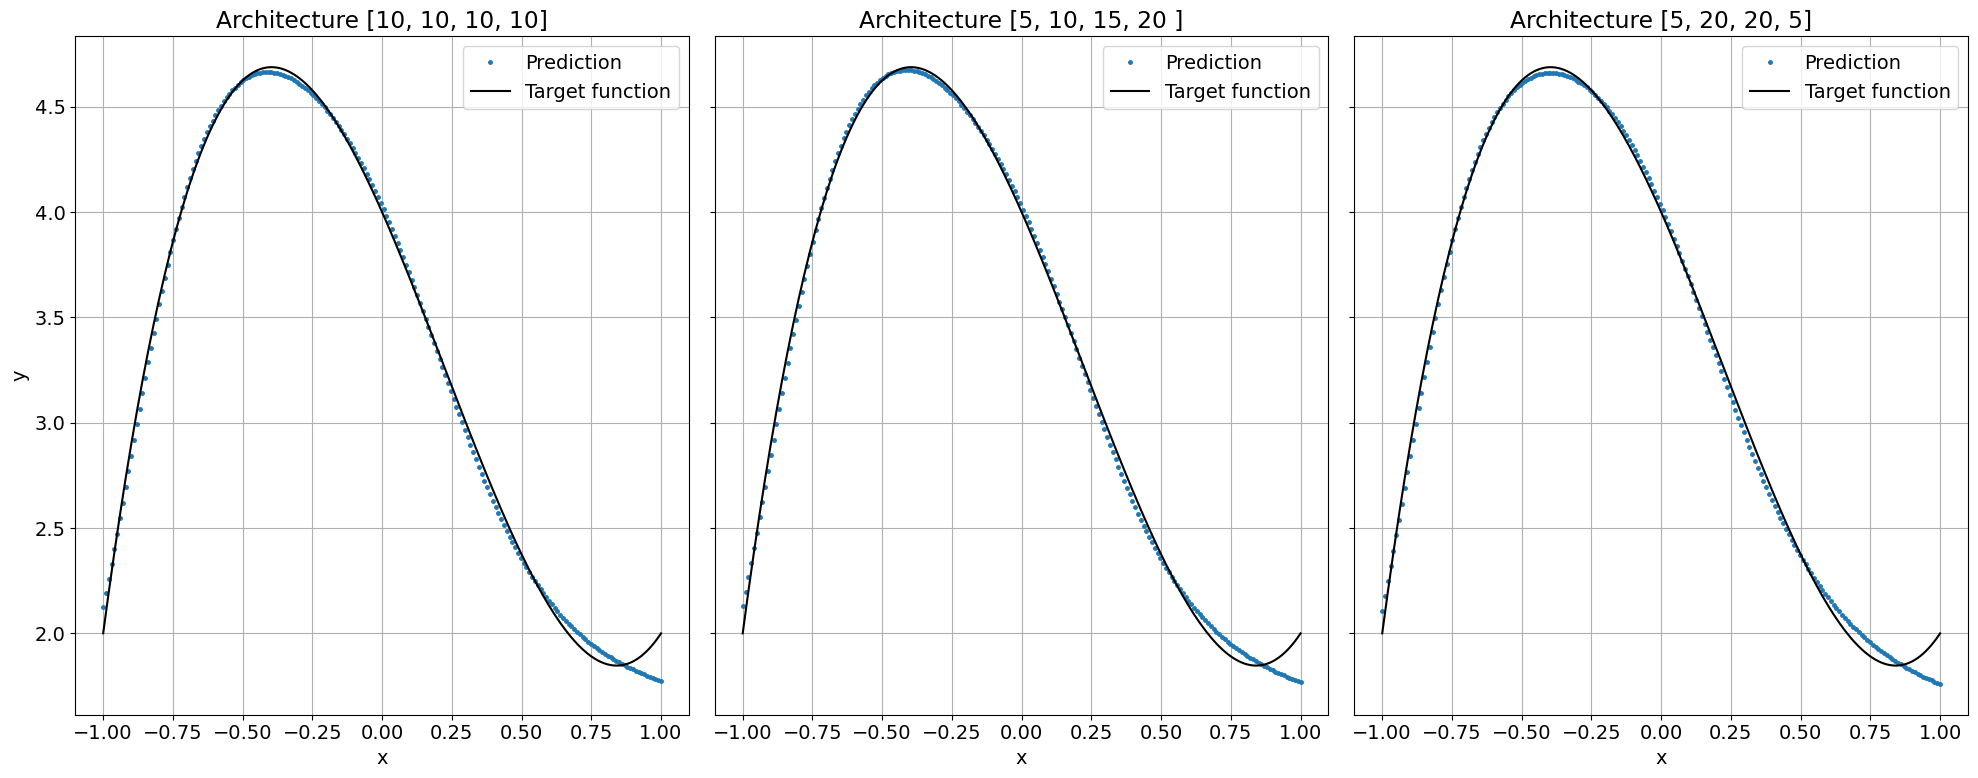

In [27]:
plot_3_fits_subplots(models, x_valid, y_valid, titles)


The figure shows the predictions of the network for different layer sizes.  
All three architectures reproduce the target function with good accuracy, confirming that the polynomial can be captured with a relatively small network.  

However, the architecture [5, 10, 15, 20] provides the best balance:  
- the fit is very close to the target function across almost the entire domain, only for values ​​of x close to 1 none of the architectures manage to represent the function,
- the network remains compact and efficient.  

For this reason, [5, 10, 15, 20] was chosen as the reference architecture in the next steps.


## Effect of the loss function and optimizer

The chosen architecture was trained with two different loss functions: mean squared error (MSE) and mean absolute error (MAE).  
In both cases, the Adam optimizer was used for training.  
The comparison focuses on the quality of the prediction and on the convergence of the training and validation losses.


In [11]:
x_train, y_train, x_valid, y_valid = generate_data(N_train=5000)
models_good=[]
histories_good=[]
loss_list=['mse','mae']
for l in loss_list:
    model=good_arch(loss=l)
    model, history = train_model(model, x_train, y_train, N_epochs=50)
    models_good.append(model)
    histories_good.append(history)

/Users/pietro34/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


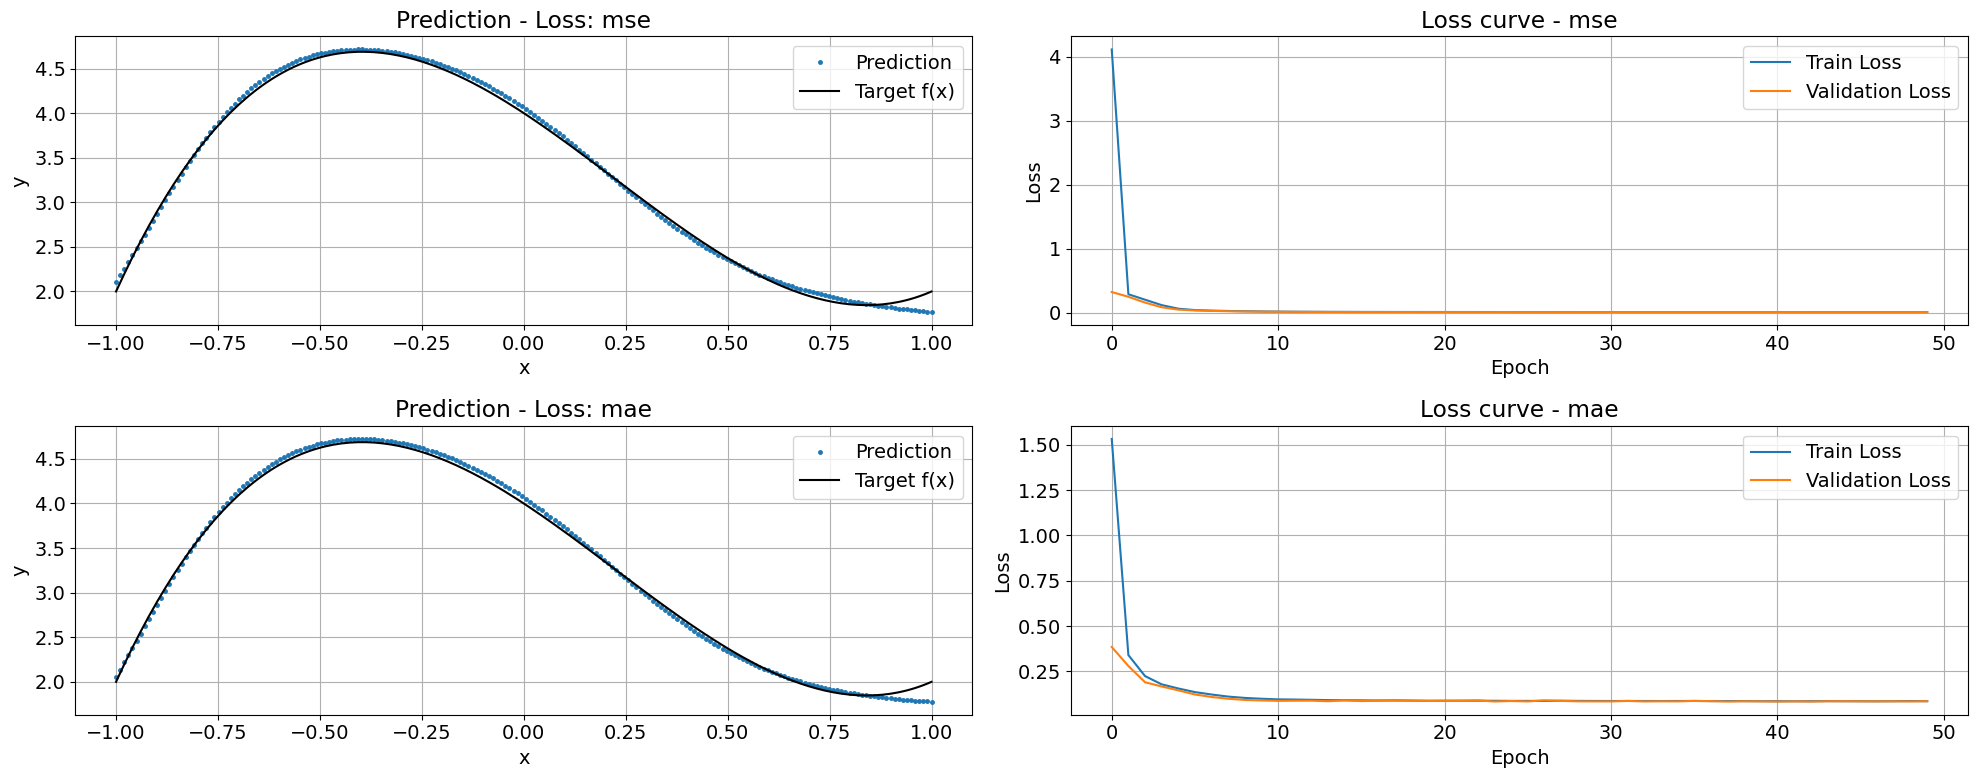

In [12]:

plot_good(models_good, histories_good, x_valid, y_valid, loss_list)
    



The figure compares the predictions and loss curves obtained with MSE (top row) and MAE (bottom row).  

- With **MSE**, the fit is accurate and the loss decreases rapidly to very small values.  
- With **MAE**, the fit is also good, although the convergence is slightly slower and the residual error is larger.  

The Adam optimizer proved to be effective in both cases, ensuring stable training.  
Overall, MSE with Adam is the most effective combination for this problem.


## Generalization outside the training domain

Finally, the performance of the selected model was tested outside the training interval.  
The network was trained on $x \in [-1, 1]$ and then evaluated on a wider range.


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


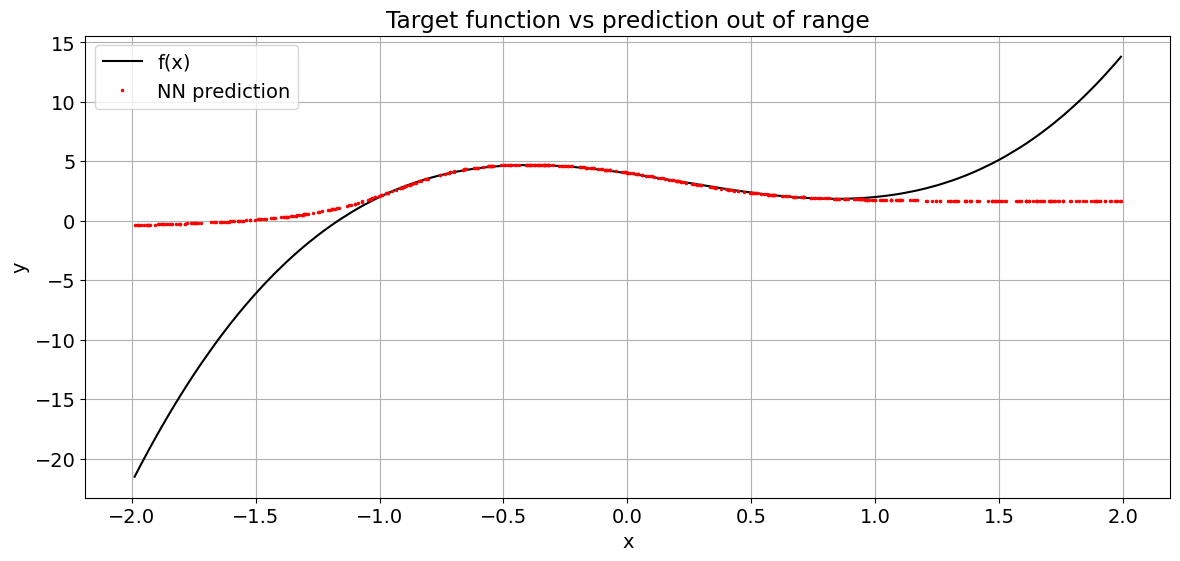

In [13]:
x_out=np.random.uniform(-2,2,500)
x_out = np.sort(x_out)
y_pred=models_good[0].predict(x_out)
plt.figure(figsize=(14,6))
plt.plot(x_out, f(x_out), label='f(x)', color='black')
plt.plot(x_out, y_pred, label='NN prediction', marker='o',markersize=1.5,linestyle='None',color='r')
plt.title('Target function vs prediction out of range')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)


The figure compares the network predictions with the true function outside the training range.  
While the model reproduces the polynomial accurately within the interval $[-1, 1]$, it fails to generalize beyond this domain.  
The predictions remain close to a constant value, completely missing the growth of the cubic polynomial for $|x| > 1$.  

This behavior is expected: the neural network only interpolates the training region and lacks extrapolation capability.  
It highlights the importance of defining the training dataset over the domain of interest.


# 11.3 <a id="section-113"></a>

In this exercise the goal is to approximate a two–dimensional function  

$$ f(x, y) = \sin(x^2 + y^2) $$  

using a feed-forward neural network.  
The training dataset was generated by sampling points $(x, y)$ uniformly in $[-1.5, 1.5]^2$, and the corresponding $z = f(x, y)$ values were computed with Gaussian noise.  
The challenge is to design a network architecture capable of capturing the non–linear structure of the function.


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # necessario per 3D

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects



In [25]:
def f(x,y):
    return np.sin(x**2+y**2)

def generate_data(N_train=1000, sigma=0.1, seed=0):
    
    np.random.seed(seed)
    x_train = np.random.uniform(-1.5,1.5 , N_train)
    y_train= np.random.uniform(-1.5,1.5, N_train)

    x_valid = np.linspace(-1.5,1.5, 200)
    y_valid=np.linspace(-1.5,1.5, 200)


    z_train = np.random.normal(f(x_train,y_train), sigma)
    z_valid = f(x_valid,y_valid)  
    return x_train, y_train, x_valid, y_valid, z_train, z_valid 
    
plt.rcParams.update({'font.size': 14})

def good_arch(act='tanh',optimizer='adam', loss='mse'):
    tf.random.set_seed(0)
    model = tf.keras.Sequential()
    model.add(Dense(10, activation=act, input_shape=(2,)))
   
    model.add(Dense(20, activation=act))
    model.add(Dense(30, activation=act))
    model.add(Dense(40, activation=act))
    
    # Layer di output
    model.add(Dense(1))
    
    # Compila il modello
    model.compile(optimizer=optimizer, loss=loss, metrics=[loss])
    return model

    
def train_model(model, x_train, y_train, z_train, 
                x_valid, y_valid, z_valid, N_epochs=60):
    # Combina x e y per formare input a 2 feature (shape: [N, 2])
    X_train = np.column_stack((x_train, y_train))
    X_valid = np.column_stack((x_valid, y_valid))
    
    # Allenamento del modello
    history = model.fit(X_train, z_train, 
                        batch_size=32,
                        epochs=N_epochs,
                        shuffle=True,
                        validation_data=(X_valid, z_valid),
                        verbose=0)
    return model, history



def plot_fit_and_loss2(model, history, x_valid, y_valid, z_valid):
    # Figure con 2 subplot
    fig = plt.figure(figsize=(14, 6))

    # -------- Subplot 1: Superficie + Punti predetti sparsi --------
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')

    # Superficie reale (griglia regolare)
    grid_x, grid_y = np.meshgrid(
        np.linspace(min(x_valid), max(x_valid), 100),
        np.linspace(min(y_valid), max(y_valid), 100)
    )
    grid_z = f(grid_x, grid_y)

    # Superficie della funzione target
    ax1.plot_surface(grid_x, grid_y, grid_z, cmap='plasma', alpha=0.5)

    # Predizioni come punti sparsi (tipo 3d.png)
    x_predicted = np.random.uniform(-1.5, 1.5, 500)
    y_predicted = np.random.uniform(-1.5,1.5,500)
    z_predicted = model.predict(np.array([x_predicted,y_predicted]).T)
    ax1.scatter(x_predicted, y_predicted, z_predicted, color='r', s=3, label='NN prediction')

    ax1.set_title('Target surface vs NN prediction')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_zlabel('f(x, y)')
    ax1.legend()

    # -------- Subplot 2: Andamento della loss --------
    ax2 = fig.add_subplot(1, 2, 2)
    ax2.plot(history.history['loss'], label='train loss')
    ax2.plot(history.history['val_loss'], label='validation loss')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoca')
    ax2.set_ylabel('MSE')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

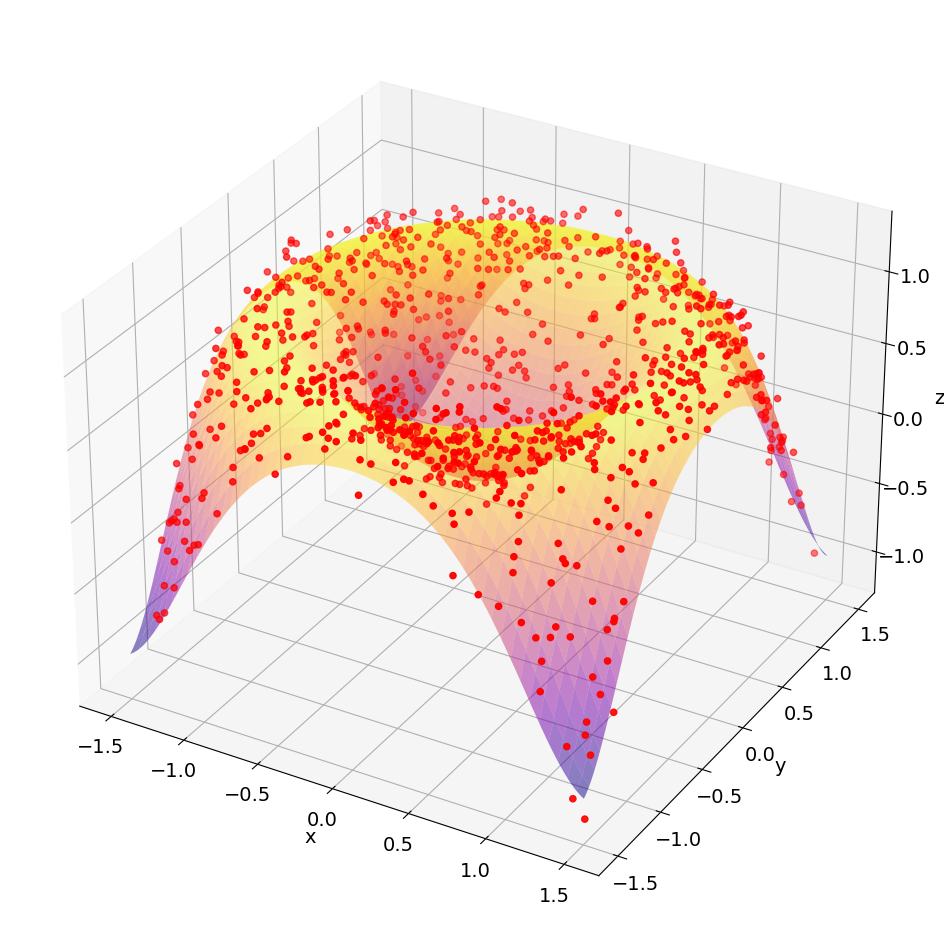

In [26]:
#generate data
x_train, y_train, x_valid, y_valid, z_train, z_valid=generate_data()

# plot validation and target dataset
fig = plt.figure(figsize = (16, 12))
ax = plt.axes(projection='3d')

X,Y = np.meshgrid(x_valid,y_valid)
ax.plot_surface(X, Y, f(X, Y) , cmap = 'plasma', alpha = 0.5)
ax.scatter3D(x_train,y_train,z_train, color='r')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

plt.show()




As a starting point, the best architecture identified in Exercise 11.2 was adapted to the two–dimensional case by **doubling the number of neurons in each layer**.  
The rationale was that the higher dimensionality requires a larger representational capacity.  
The network was trained with the Adam optimizer and mean squared error (MSE) loss.


In [27]:
model=good_arch()
model_train, history=train_model(model, x_train, y_train, z_train, 
                x_valid, y_valid, z_valid)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


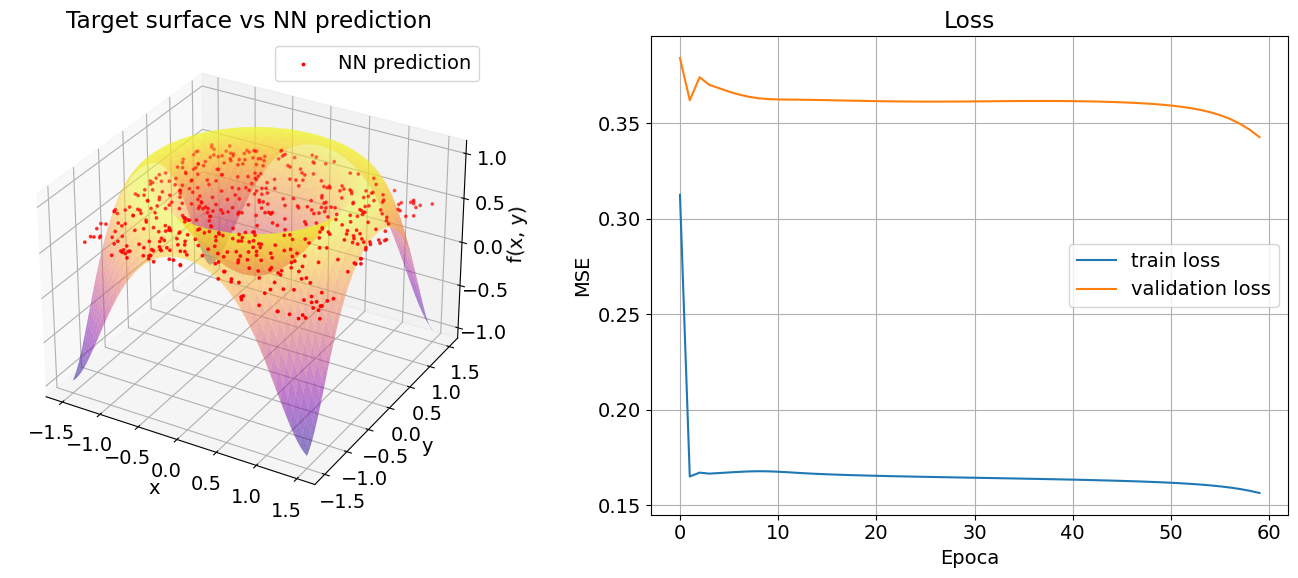

In [28]:
plot_fit_and_loss2(model_train, history,x_valid, y_valid, z_valid)



The figure shows that the network fails to approximate the target surface.  
Although the training loss decreases, the validation loss remains high and does not follow the same downward trend.  
This indicates that the model does not learn the underlying mapping correctly.  
The predicted surface departs significantly from the true function, demonstrating that simply scaling up the architecture from Exercise 11.2 is not sufficient for the two–dimensional case.


## Second architecture

Since the first model did not generalize properly, the network architecture was modified.  
In particular, **two additional hidden layers with 40 neurons each** were added at the end of the network.  
The aim was to increase the expressive power of the model while keeping the training procedure identical, using the Adam optimizer and MSE loss.


In [29]:
def set_model(act='tanh',optimizer='adam', loss='mse'):
    tf.random.set_seed(0)
    model = tf.keras.Sequential()
    model.add(Dense(10, activation=act, input_shape=(2,)))
   
    model.add(Dense(20, activation=act))
    model.add(Dense(30, activation=act))
    model.add(Dense(40, activation=act))
    model.add(Dense(40, activation=act))
    model.add(Dense(40, activation=act))
    
    # Layer di output
    model.add(Dense(1))
    
    # Compila il modello
    model.compile(optimizer=optimizer, loss=loss, metrics=[loss])
    return model

In [30]:
model=set_model()
model_train, history=train_model(model, x_train, y_train, z_train, 
                x_valid, y_valid, z_valid)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


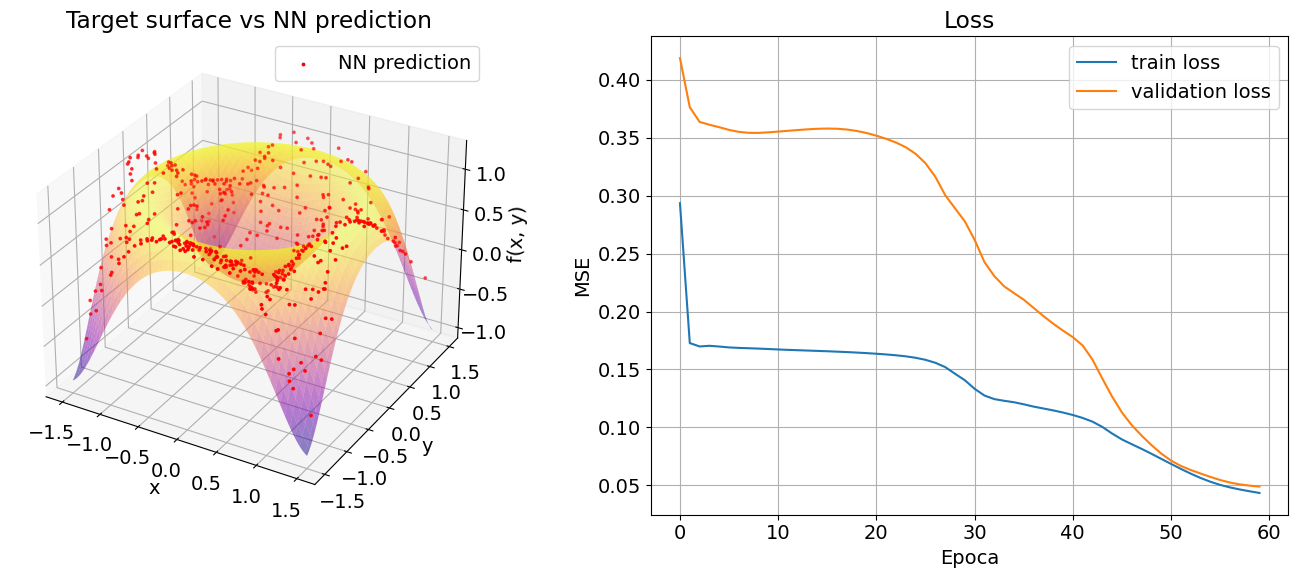

In [31]:
plot_fit_and_loss2(model_train, history,x_valid, y_valid, z_valid)

The second network shows a clear improvement over the first architecture.
The training loss decreases rapidly, while the validation loss, although consistently higher, follows a similar downward trend. This indicates that the model is not overfitting and is effectively learning the underlying function.
The predicted surface captures the overall shape of the target function with higher accuracy, with only minor deviations remaining in regions of high curvature.

Adding two additional layers with 40 neurons each allowed the model to better approximate the two–dimensional function.
This highlights that higher–dimensional problems often require a tailored architectural adjustment, rather than a simple rescaling of one–dimensional solutions.